# LATAM dispute-service analytics

This notebook turns the synthetic hackathon lakehouse into decision-ready baselines for a safer,
faster and more sustainable dispute journey. It reads the treated DuckDB/MotherDuck tables in
`lakehouse.silver`; changing `MOTHERDUCK_DATABASE` or `MOTHERDUCK_SCHEMA` is enough to point it at
another treated environment.

**Scope:** synthetic data only. Results describe this dataset—not real customers, national
prevalence, causal effects, fraud, liability, a chargeback outcome or a final Visa code. Public
outputs are aggregate-only.

## 0. Setup and source contract

Set `MOTHERDUCK_TOKEN` in `.env` locally or in the environment. The token is never printed or
embedded in the connection string. Every table section starts by creating a dataframe from its
treated source or an aggregate query.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

project_root = Path.cwd()
if not (project_root / "analytics").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
load_dotenv(project_root / ".env")

from analytics.data import AnalyticsRepository, connect_motherduck

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

database = os.getenv("MOTHERDUCK_DATABASE", "lakehouse")
schema = os.getenv("MOTHERDUCK_SCHEMA", "silver")
repo = AnalyticsRepository(connect_motherduck(database=database), catalog=database, schema=schema)
available_tables = repo.available_tables()
inventory = repo.data_inventory()
display(inventory)

/Users/silvs/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/vk/rw3fbc110n3fsf_xhz6_r4m00000gn/T/matplotlib-s4e36xs5 because there was an issue with the default path (/Users/silvs/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:181: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:181: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:181: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted


,table_name,columns
0,branches,26
1,call_center_interactions,24
2,call_transcripts,21
3,complaints,30
4,customers,33
5,products,23
6,service_agents,27
7,transactions,24


## 1. Dispute intake and baseline

`CARGO NO RECONOCIDO` and `COBRO INDEBIDO` are synthetic intake labels. They are useful for finding
potential disputes, but they are not final classifications. Linking to `products` restricts the
baseline to credit and debit cards.

In [2]:
headline_metrics = pd.DataFrame([repo.headline_metrics()])
card_disputes_by_label = repo.card_dispute_breakdown("subcategory")
card_disputes_by_country = repo.card_dispute_breakdown("country")
card_disputes_by_channel = repo.card_dispute_breakdown("channel")
card_disputes_by_status = repo.card_dispute_breakdown("status")
country_experience = repo.card_dispute_country_experience()
card_dispute_trend = repo.card_dispute_monthly_trend()
display(headline_metrics)
display(country_experience)
display(card_dispute_trend.tail(12))

,complaints,dispute_intake,card_disputes,call_center_cases,sla_breach_pct,repeat_complainer_pct,median_resolution_days,p90_resolution_days,origin_link_pct
0,67095.0,24491.0,5207.0,2624.0,20.606875,14.768581,16.0,28.0,0.0


,country,cases,call_center_pct,sla_breach_pct,repeat_complainer_pct,median_resolution_days,p90_resolution_days
0,MEXICO,2477,51.029471,21.033508,14.654824,16.0,28.0
1,COLOMBIA,1522,51.379763,19.710907,16.162943,16.0,27.0
2,ARGENTINA,988,47.975709,20.242915,12.753036,16.0,27.0
3,MISSING,220,47.272727,23.636364,15.454545,16.0,27.0


,month,cases,sla_breach_pct,median_resolution_days,compensation_granted
25,2025-07-01,130,26.923077,18.0,2246.45
26,2025-08-01,142,17.605634,16.0,3406.11
27,2025-09-01,129,19.379845,13.0,1712.37
28,2025-10-01,146,19.178082,16.0,2291.56
29,2025-11-01,148,20.945946,22.0,1412.37
30,2025-12-01,135,20.000000,12.5,3019.44
31,2026-01-01,137,15.328467,19.0,3403.78
32,2026-02-01,142,21.830986,18.0,2118.97
33,2026-03-01,171,21.637427,18.0,2062.66
34,2026-04-01,138,23.913043,15.5,3828.48


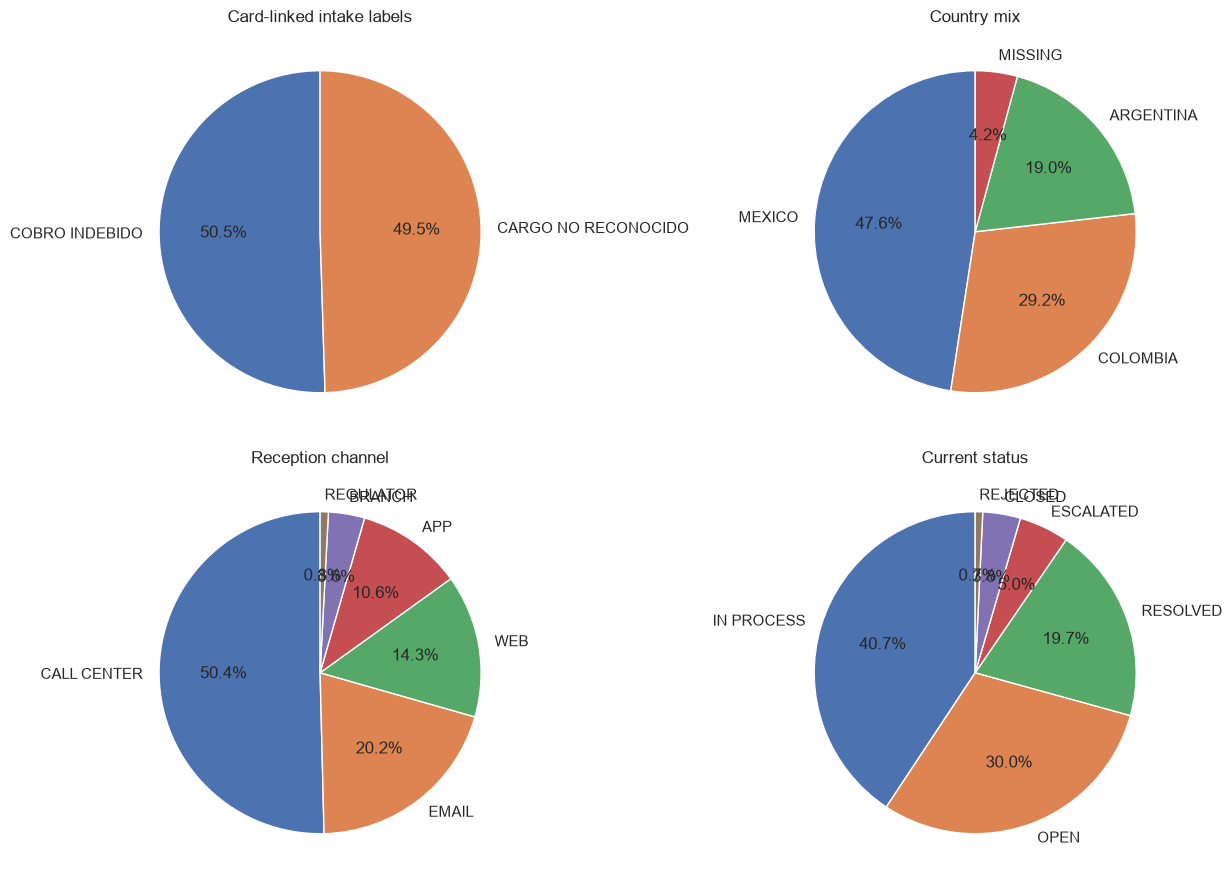

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, frame, title in [
    (axes[0, 0], card_disputes_by_label, "Card-linked intake labels"),
    (axes[0, 1], card_disputes_by_country, "Country mix"),
    (axes[1, 0], card_disputes_by_channel, "Reception channel"),
    (axes[1, 1], card_disputes_by_status, "Current status"),
]:
    ax.pie(frame["cases"], labels=frame["category"], autopct="%1.1f%%", startangle=90)
    ax.set_title(title)
plt.tight_layout()
plt.show()

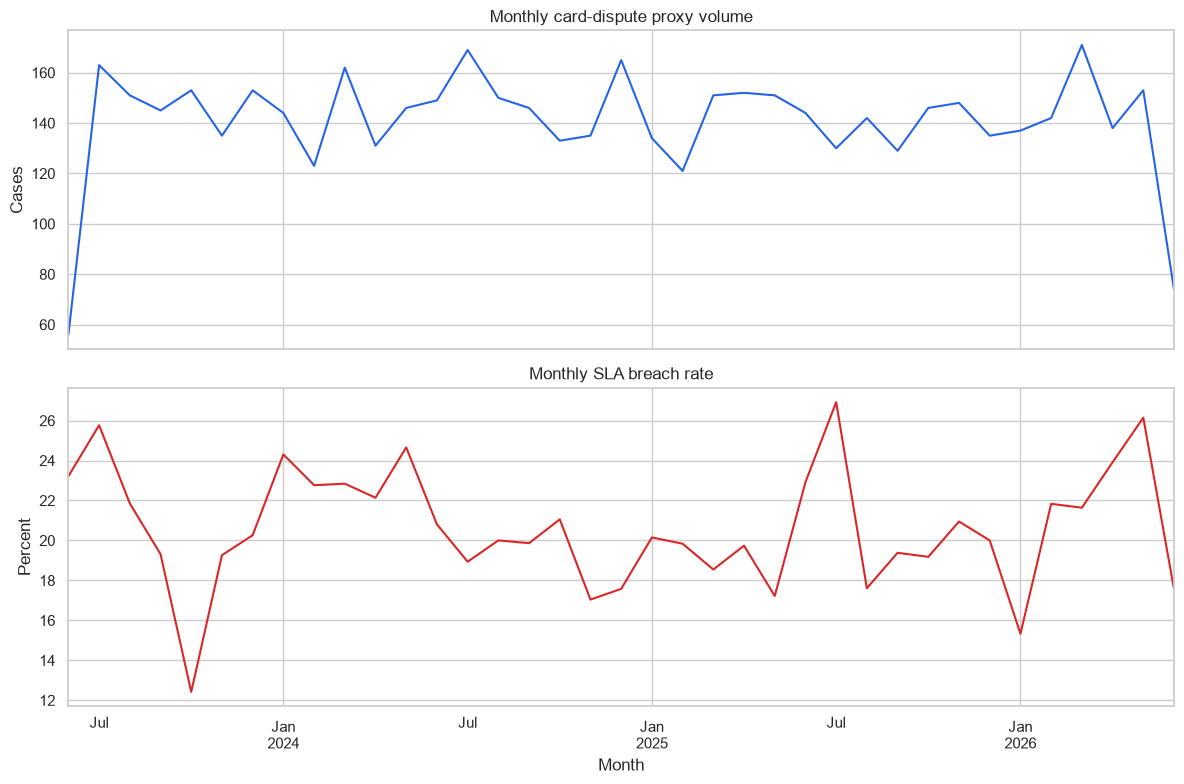

In [4]:
trend_plot = card_dispute_trend.set_index("month")
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
trend_plot["cases"].plot(ax=axes[0], color="#2563eb", title="Monthly card-dispute proxy volume")
trend_plot["sla_breach_pct"].plot(ax=axes[1], color="#dc2626", title="Monthly SLA breach rate")
axes[0].set_ylabel("Cases")
axes[1].set_ylabel("Percent")
axes[1].set_xlabel("Month")
plt.tight_layout()
plt.show()

### What the baseline means

- Use the intake-label count to size **demand**, and the card-linked count to size the current
  product scope.
- Compare call-center share, SLA breaches, repeat complainants and resolution time before and after
  the solution. Counts alone are not success metrics.
- Country comparisons are operational diagnostics. They should trigger investigation, not unequal
  treatment.

## 2. Transactions and products

This section creates the transaction/product aggregate dataframe. It helps the team understand
which product and transaction combinations create search volume without exposing customer rows.

,product_type,transaction_type,transactions,amount_usd
0,CREDIT CARD,PURCHASE,719975,7.735335e+07
1,SAVINGS ACCOUNT,TRANSFER,431851,9.310544e+08
2,SAVINGS ACCOUNT,WITHDRAWAL,370328,4.098931e+07
3,CHECKING ACCOUNT,TRANSFER,359549,7.749094e+08
4,CHECKING ACCOUNT,WITHDRAWAL,308824,3.431157e+07
5,SAVINGS ACCOUNT,DEPOSIT,308152,3.318324e+08
6,DEBIT CARD,PURCHASE,286130,3.117490e+07
7,CHECKING ACCOUNT,DEPOSIT,257359,2.793767e+08
8,CREDIT CARD,WITHDRAWAL,154572,1.726972e+07
9,CREDIT CARD,PAYMENT,153973,6.721983e+07


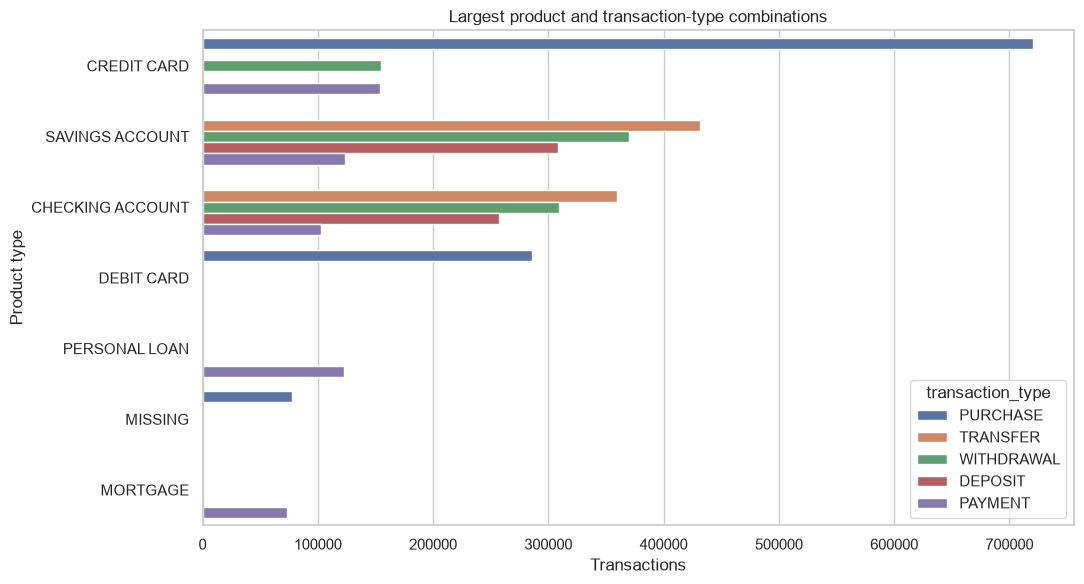

In [5]:
transaction_mix = repo.product_transaction_mix()
display(transaction_mix.head(20))

top_transaction_mix = transaction_mix.nlargest(15, "transactions")
plt.figure(figsize=(11, 6))
sns.barplot(top_transaction_mix, x="transactions", y="product_type", hue="transaction_type")
plt.title("Largest product and transaction-type combinations")
plt.xlabel("Transactions")
plt.ylabel("Product type")
plt.tight_layout()
plt.show()

## 3. Call-center interactions

`was_resolved` is used as an FCR proxy because the source says it indicates resolution on the first
call. Production FCR should also verify that the same issue did not generate another contact inside
a defined window.

In [6]:
call_outcomes = repo.call_center_outcomes("reason_category")
call_channels = repo.call_center_outcomes("channel")
accent_alignment = repo.accent_alignment()
display(call_outcomes)
display(call_channels)

,category,interactions,mean_wait_seconds,median_wait_seconds,p90_wait_seconds,mean_duration_seconds,p90_duration_seconds,fcr_proxy_pct,followup_pct,escalation_pct
0,TRANSACTIONAL,240056,119.650225,119.0,196.0,220.802824,333.0,91.508231,22.135252,9.931433
1,PRODUCT,150863,119.963176,119.0,196.0,266.382000,379.0,89.626350,23.811670,9.956716
2,COMPLAINT,117021,119.982118,120.0,197.0,434.605915,608.0,43.599867,62.968185,10.026406
3,TECHNICAL,102899,120.184581,119.0,196.0,360.462376,499.0,69.931681,40.586400,10.074928
4,COMMERCIAL,54879,120.206505,120.0,197.0,539.935049,747.0,65.208914,44.545272,9.836185
5,RETENTION,20578,120.880799,120.0,196.0,479.239703,665.0,60.161337,49.076684,9.845466


,category,interactions,mean_wait_seconds,median_wait_seconds,p90_wait_seconds,mean_duration_seconds,p90_duration_seconds,fcr_proxy_pct,followup_pct,escalation_pct
0,PHONE,583250,119.937081,119.0,196.0,321.458947,538.0,76.627690,34.841320,9.947707
1,EMAIL,27543,NaN,NaN,NaN,NaN,NaN,76.807174,34.408017,10.187706
2,APP,26364,NaN,NaN,NaN,321.023998,537.0,77.127902,34.547110,9.987104
3,WHATSAPP,22888,NaN,NaN,NaN,NaN,NaN,76.577246,35.263020,9.909123
4,WEB CHAT,22856,NaN,NaN,NaN,NaN,NaN,76.474449,35.102380,10.071754
5,WEB,3395,NaN,NaN,NaN,321.131664,536.0,76.701031,34.256259,10.515464


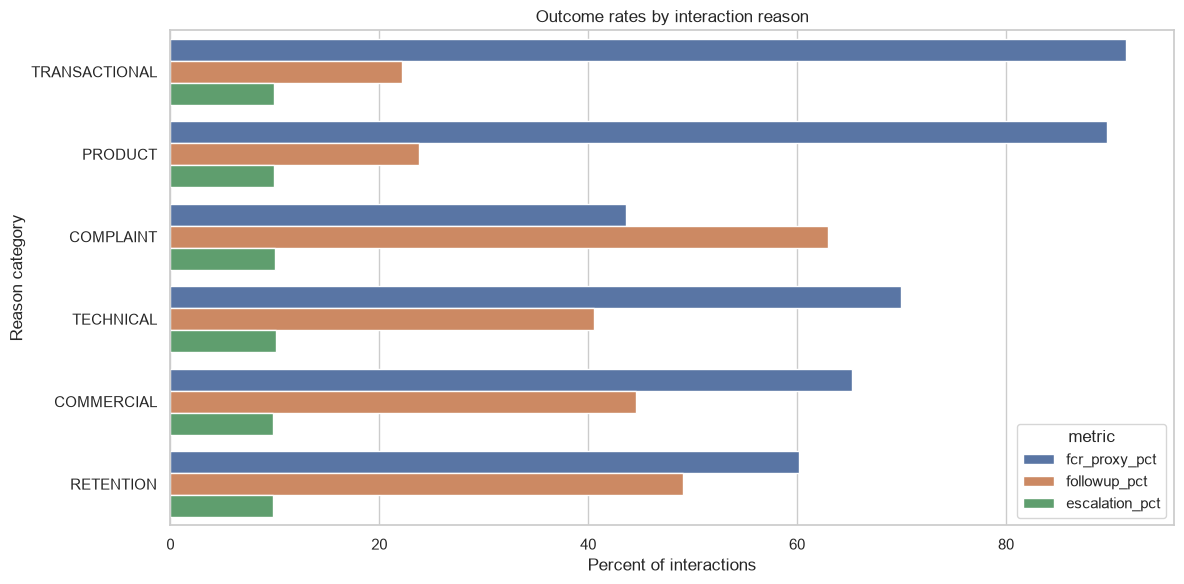

In [7]:
plot_frame = call_outcomes.melt(
    id_vars=["category", "interactions"],
    value_vars=["fcr_proxy_pct", "followup_pct", "escalation_pct"],
    var_name="metric",
    value_name="percent",
)
plt.figure(figsize=(12, 6))
sns.barplot(plot_frame, x="percent", y="category", hue="metric")
plt.title("Outcome rates by interaction reason")
plt.xlabel("Percent of interactions")
plt.ylabel("Reason category")
plt.tight_layout()
plt.show()

## 4. Language and accent experience

Accent alignment is a quality diagnostic only. It must never determine identity, authentication,
eligibility, liability, priority or an adverse decision. Differences are descriptive and may be
confounded by channel, reason, country, availability or routing.

,accent_alignment,interactions,mean_wait_seconds,mean_duration_seconds,fcr_proxy_pct,followup_pct,escalation_pct
0,MATCH,392039,119.898866,321.292619,76.683187,34.836075,9.973242
1,MISSING,204750,119.908635,321.561747,76.604640,34.805861,9.959463
2,MISMATCH,89507,120.169458,321.917522,76.590658,34.877719,9.937770


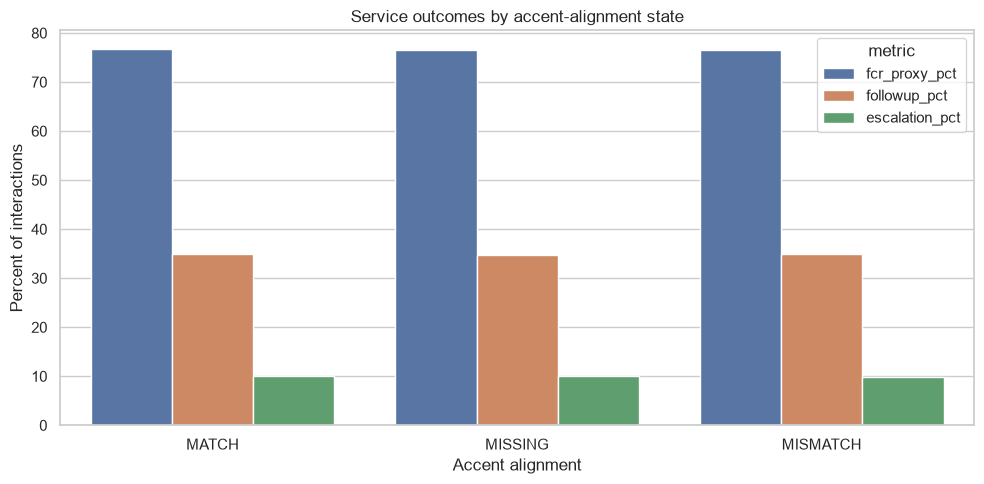

In [8]:
display(accent_alignment)

accent_plot = accent_alignment.melt(
    id_vars=["accent_alignment", "interactions"],
    value_vars=["fcr_proxy_pct", "followup_pct", "escalation_pct"],
    var_name="metric",
    value_name="percent",
)
plt.figure(figsize=(10, 5))
sns.barplot(accent_plot, x="accent_alignment", y="percent", hue="metric")
plt.title("Service outcomes by accent-alignment state")
plt.xlabel("Accent alignment")
plt.ylabel("Percent of interactions")
plt.tight_layout()
plt.show()

## 5. Transcripts, recordings and case lineage

This section measures whether the evidence needed to audit and improve a dispute journey exists.
It does not display transcript text.

In [9]:
transcript_coverage = repo.transcript_coverage()
complaint_linkage = repo.complaint_linkage_quality()
display(transcript_coverage)
display(complaint_linkage)

,reason_category,interactions,transcript_available_pct,recording_available_pct,fcr_proxy_pct
0,TRANSACTIONAL,240056,24.905022,86.007015,91.508231
1,PRODUCT,150863,24.961720,85.934921,89.626350
2,COMPLAINT,117021,24.951077,86.076003,43.599867
3,TECHNICAL,102899,24.967201,85.999864,69.931681
4,COMMERCIAL,54879,25.160808,85.792380,65.208914
5,RETENTION,20578,25.172514,85.776072,60.161337


,complaints,customer_link_pct,product_link_pct,interaction_link_pct,agent_link_pct,resolution_days_available_pct
0,67095,100.0,66.428199,0.0,65.548849,22.897384


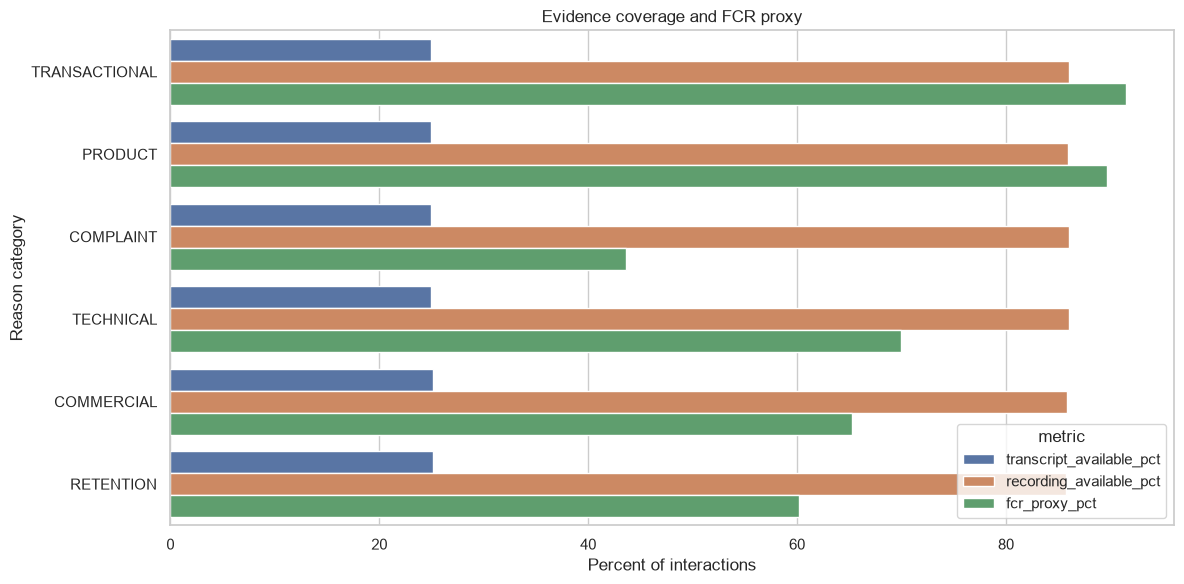

In [10]:
coverage_plot = transcript_coverage.melt(
    id_vars=["reason_category", "interactions"],
    value_vars=["transcript_available_pct", "recording_available_pct", "fcr_proxy_pct"],
    var_name="metric",
    value_name="percent",
)
plt.figure(figsize=(12, 6))
sns.barplot(coverage_plot, x="percent", y="reason_category", hue="metric")
plt.title("Evidence coverage and FCR proxy")
plt.xlabel("Percent of interactions")
plt.ylabel("Reason category")
plt.tight_layout()
plt.show()

## 6. Service agents and operational sustainability

The cost model is an illustrative planning proxy, not payroll. Annual base proxies in USD are:
Colombia 7,200; Mexico 7,575; Argentina 10,200. Experience multipliers are 1.00 (Junior), 1.45
(Mid-Senior), 1.50 (Specialist) and 1.62 (Senior), followed by a 1.42 loaded-cost multiplier and 132
productive hours/month. Cost then uses each interaction's observed duration.

Sources and rationale: [Nearshore Business Solutions 2025 ranges](https://nearshorebusinesssolutions.com/call-center-representatives/)
and [HireTalent LATAM planning ranges](https://blog.hiretalent.lat/latin-america-call-center-agent-cost/).
Replace these assumptions with bank-specific fully loaded rates before financial decisions.

In [11]:
agent_capacity = repo.agent_capacity()
interaction_costs = repo.interaction_cost_proxy()
display(agent_capacity)
display(interaction_costs)

,agent_type,experience_level,country,agents,mean_agent_csat,median_agent_csat,monthly_interactions,mean_monthly_interactions
0,PHONE,SPECIALIST,MEXICO,189,4.254277,4.26,78372.0,461.011765
1,PHONE,SPECIALIST,COLOMBIA,126,4.308113,4.36,51107.0,444.408696
2,PHONE,SPECIALIST,ARGENTINA,72,4.292222,4.26,30381.0,467.400000
3,DIGITAL,SPECIALIST,MEXICO,73,4.352941,4.41,29045.0,427.132353
4,IN-PERSON,SPECIALIST,MEXICO,72,4.281111,4.35,28344.0,457.161290
5,PHONE,SENIOR,MEXICO,71,4.240678,4.26,25068.0,410.950820
6,DIGITAL,SPECIALIST,COLOMBIA,51,4.221667,4.14,21043.0,447.723404
7,HYBRID,SPECIALIST,MEXICO,38,4.205833,4.25,17893.0,497.027778
8,PHONE,SENIOR,COLOMBIA,37,4.276667,4.34,15901.0,467.676471
9,PHONE,MID-SENIOR,MEXICO,35,4.212500,4.17,15715.0,476.212121


,reason_category,interactions,priced_interactions,mean_duration_minutes,mean_labor_cost_usd,p90_labor_cost_usd,total_labor_cost_proxy_usd
0,TRANSACTIONAL,240056,240056,3.680047,0.663459,1.032755,136981.054112
1,COMPLAINT,117021,117021,7.243432,1.307672,1.898572,131717.839381
2,PRODUCT,150863,150863,4.439700,0.800513,1.175265,103781.715518
3,TECHNICAL,102899,102899,6.007706,1.083776,1.554470,95906.595246
4,COMMERCIAL,54879,54879,8.998917,1.624095,2.328651,76465.634979
5,RETENTION,20578,20578,7.987328,1.440101,2.070833,25419.214341


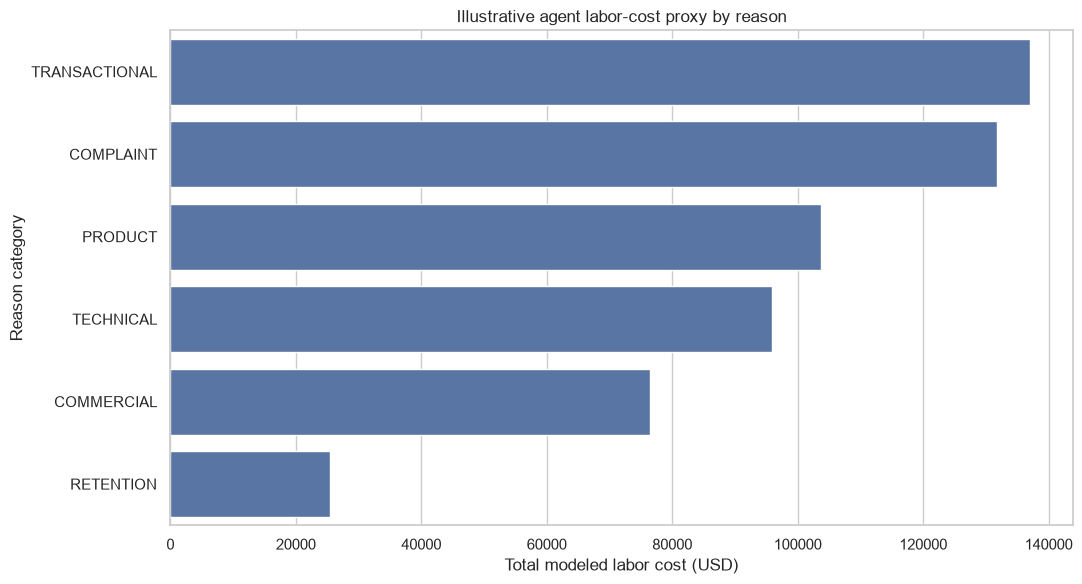

In [12]:
plt.figure(figsize=(11, 6))
sns.barplot(interaction_costs, x="total_labor_cost_proxy_usd", y="reason_category")
plt.title("Illustrative agent labor-cost proxy by reason")
plt.xlabel("Total modeled labor cost (USD)")
plt.ylabel("Reason category")
plt.tight_layout()
plt.show()

## 7. Satisfaction surveys and digital events

The original workbench anticipated `satisfaction_surveys` and `digital_events`. They are not
present in the current `lakehouse.silver` contract, so this notebook does not fabricate metrics.
Once treated tables are published, add them to the inventory and implement aggregate adapters in
`analytics/data.py`.

In [13]:
missing_expected_tables = sorted({"satisfaction_surveys", "digital_events"} - available_tables)
pd.DataFrame({"unavailable_table": missing_expected_tables})

,unavailable_table
0,digital_events
1,satisfaction_surveys


## 8. Prioritized product opportunities and scorecard

1. **Create immutable lineage.** Case creation should atomically link customer, interaction,
   transcript, selected transaction, product and agent/tool actions. Monitor linkage coverage.
2. **Reduce complaint rework.** Ask one answerable question at a time, rank candidate transactions,
   confirm the selected transaction and classification, then preserve the customer statement.
   Monitor FCR proxy, follow-up, escalation and repeated complaints.
3. **Make automation safe.** LLMs can understand and summarize; deterministic/versioned rules
   authorize irreversible actions. Monitor abstention, tool success, override and rollback rates.
4. **Use humans where judgment matters.** Handoff ambiguity, denial, missing evidence and risky
   actions with a structured summary. Monitor handoff completion and context-repetition rate.
5. **Improve efficiency without hiding failures.** Track wait time, duration and cost alongside SLA,
   customer outcomes, evidence completeness and auditability.

In [14]:
metrics = headline_metrics.iloc[0]
scorecard = pd.DataFrame([
    ["Card dispute demand", "card_disputes", metrics["card_disputes"], "Trend, not target"],
    ["Call-center share", "call_center_cases/card_disputes", 100 * metrics["call_center_cases"] / metrics["card_disputes"], "Context"],
    ["SLA breach rate", "sla_breach_pct", metrics["sla_breach_pct"], "Lower"],
    ["Repeat complainants", "repeat_complainer_pct", metrics["repeat_complainer_pct"], "Lower"],
    ["Median resolution days", "median_resolution_days", metrics["median_resolution_days"], "Lower"],
    ["P90 resolution days", "p90_resolution_days", metrics["p90_resolution_days"], "Lower"],
    ["Origin interaction linkage", "origin_link_pct", metrics["origin_link_pct"], "Higher"],
], columns=["business_question", "metric", "baseline", "desired_direction"])
display(scorecard)

,business_question,metric,baseline,desired_direction
0,Card dispute demand,card_disputes,5207.000000,"Trend, not target"
1,Call-center share,call_center_cases/card_disputes,50.393701,Context
2,SLA breach rate,sla_breach_pct,20.606875,Lower
3,Repeat complainants,repeat_complainer_pct,14.768581,Lower
4,Median resolution days,median_resolution_days,16.000000,Lower
5,P90 resolution days,p90_resolution_days,28.000000,Lower
6,Origin interaction linkage,origin_link_pct,0.000000,Higher


## 9. Public delivery and AWS BI options

The accompanying Streamlit app is the recommended hackathon publication path: it connects directly
to MotherDuck, caches aggregate queries and can be hosted free on Streamlit Community Cloud. Store
`MOTHERDUCK_TOKEN` in the platform's encrypted secrets, never in Git.

For an AWS-native future state:

- Amazon QuickSight/Quick can query Aurora PostgreSQL directly or query Parquet in S3 through
  Athena. It does not query a DuckDB file directly.
- Public dashboard sharing requires Enterprise/public sharing and anonymous capacity; this is
  materially more expensive than the hackathon Streamlit path.
- Official references: [supported data sources](https://docs.aws.amazon.com/quick/latest/userguide/supported-data-sources.html),
  [public dashboard sharing](https://docs.aws.amazon.com/quick/latest/userguide/share-a-dashboard-grant-access-anyone.html),
  and [pricing](https://aws.amazon.com/quicksuite/quicksight/pricing/).